/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
40/40 - 18s - 442ms/step - loss: 0.0350 - val_loss: 0.0706
Epoch 2/20
40/40 - 19s - 483ms/step - loss: 0.0058 - val_loss: 0.0553
Epoch 3/20
40/40 - 11s - 276ms/step - loss: 0.0035 - val_loss: 0.0774
Epoch 4/20
40/40 - 10s - 254ms/step - loss: 0.0026 - val_loss: 0.0535
Epoch 5/20
40/40 - 10s - 248ms/step - loss: 0.0022 - val_loss: 0.0867
Epoch 6/20
40/40 - 9s - 227ms/step - loss: 0.0023 - val_loss: 0.0602
Epoch 7/20
40/40 - 12s - 311ms/step - loss: 0.0021 - val_loss: 0.0561
Epoch 8/20
40/40 - 12s - 306ms/step - loss: 0.0020 - val_loss: 0.0630
Epoch 9/20
40/40 - 19s - 479ms/step - loss: 0.0018 - val_loss: 0.0581
Epoch 10/20
40/40 - 19s - 463ms/step - loss: 0.0014 - val_loss: 0.0435
Epoch 11/20
40/40 - 10s - 258ms/step - loss: 0.0015 - val_loss: 0.0527
Epoch 12/20
40/40 - 12s - 289ms/step - loss: 0.0015 - val_loss: 0.0699
Epoch 13/20
40/40 - 20s - 504ms/step - loss: 0.0017 - val_loss: 0.0443
Epoch 14/20
40/40 - 10s - 258ms/step - loss: 0.0020 - val_loss: 0.0406
Epoch 15/20
40/4

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 205ms/step
[('ActiveCases', 0.021504816938792515), ('Recovered', 0.021847474293356987), ('Hospitalized', 0.017290259199282322), ('ICU', 0.020675077691190383), ('Deaths', 0.021052088114056254)]


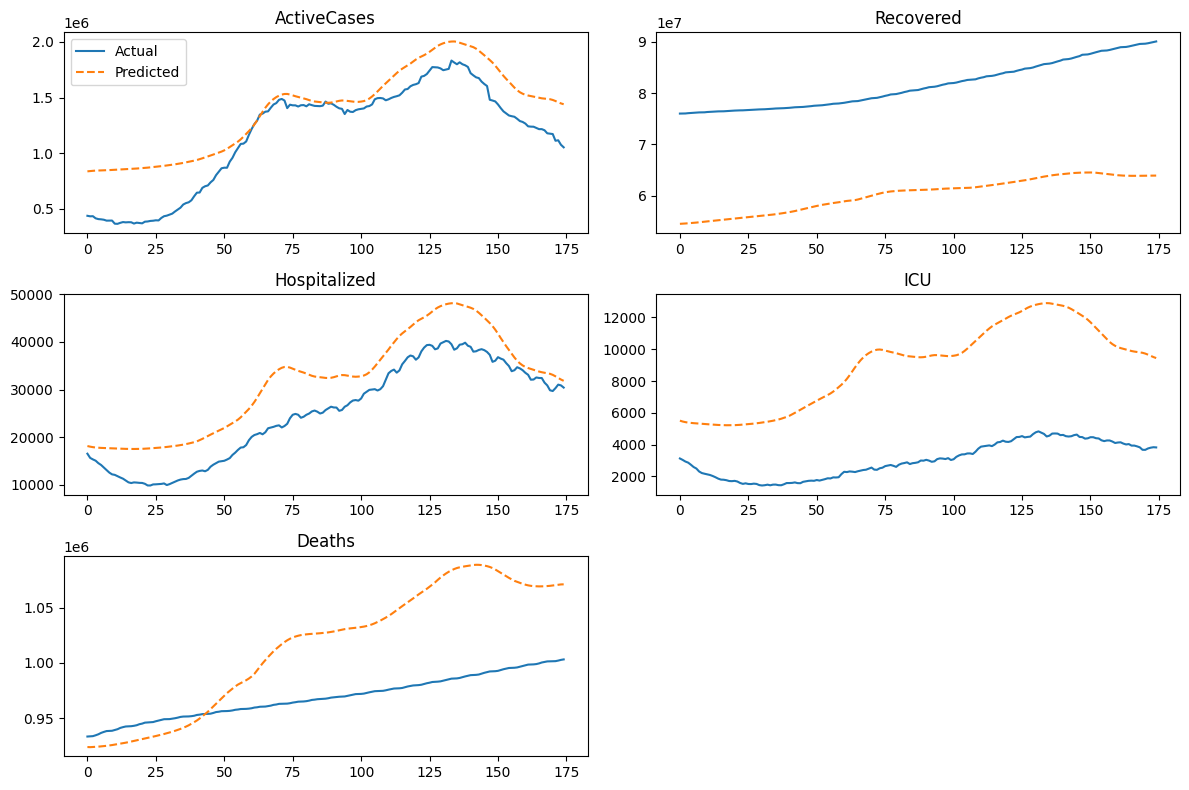

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

data = pd.read_csv(
    "https://storage.googleapis.com/covid19-open-data/v3/location/US.csv",
    parse_dates=["date"]
)
data = data.reset_index(drop=True).iloc[80:-3].copy()
data["Recovered"]    = data["cumulative_confirmed"].shift(14).fillna(0) - data["cumulative_deceased"]
data["ActiveCases"]  = data["cumulative_confirmed"] - data["Recovered"] - data["cumulative_deceased"]
data["Hospitalized"] = data["current_hospitalized_patients"]
data["ICU"]          = data["current_intensive_care_patients"]
data["Deaths"]       = data["cumulative_deceased"]
data = data[["ActiveCases","Recovered","Hospitalized","ICU","Deaths"]].fillna(0)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data.values)
n_features  = scaled_data.shape[1]

T_in, T_out = 30, 7
X, y = [], []
for i in range(len(scaled_data) - T_in - T_out + 1):
    X.append(scaled_data[i : i+T_in, :])
    y.append(scaled_data[i+T_in : i+T_in+T_out, :])

X = np.stack(X)
y = np.stack(y).reshape(-1, T_out * n_features)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([
    LSTM(300, input_shape=(T_in, n_features), return_sequences=True),
    Dropout(0.2),
    LSTM(300, return_sequences=True),
    Dropout(0.2),
    LSTM(200, return_sequences=False),
    Dropout(0.2),
    Dense(200, activation="relu"),
    Dense(200, activation="relu"),
    Dense(150, activation="relu"),
    Dense(T_out * n_features, activation="linear"),
])
model.compile(loss="mse", optimizer="adam")

es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=16,
    callbacks=[es],
    verbose=2
)

y_pred_flat = model.predict(X_test)
y_pred = y_pred_flat.reshape(-1, T_out, n_features)
y_true = y_test.reshape(-1, T_out, n_features)


from sklearn.metrics import mean_squared_error

labels = data.columns.tolist()

mse_values = []
for i in range(len(labels)):
    mse = mean_squared_error(y_true[:, i], y_pred[:, i])
    mse_values.append((labels[i], mse))

print(mse_values)


y_pred_day1 = y_pred[:, 0, :]
y_true_day1 = y_true[:, 0, :]
inv_pred = scaler.inverse_transform(y_pred_day1)
inv_true = scaler.inverse_transform(y_true_day1)

dates  = np.arange(len(inv_true))

plt.figure(figsize=(12, 8))
for i, name in enumerate(labels):
    ax = plt.subplot(3, 2, i+1)
    ax.plot(dates, inv_true[:, i],  label="Actual")
    ax.plot(dates, inv_pred[:, i],  label="Predicted", linestyle="--")
    ax.set_title(name)
    if i == 0:
        ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
model.save_weights("lstm_covid_model_weights_new.weights.h5")

In [ ]:
y_test.shape

(175, 35)